In [1]:
import mysql.connector
from dotenv import load_dotenv
import os

load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password=os.getenv('MYSQL_PASSWORD'),
    database='claims_practice'
)

print("Connection successful" if conn.is_connected() else "Connection failed")

Connection successful


In [3]:
import os
print(os.getcwd())

/Users/douglas/Documents/GitHub/claims_readmission_analysis/analysis


In [7]:
import pandas as pd

with open('../queries/06_readmission_by_drg.sql', 'r') as f:
    query = f.read()
df = pd.read_sql(query, conn)
print(df.head())

/var/folders/4_/dbg0kzhn7354xv35_by_4slr0000gn/T/ipykernel_40656/287868812.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  CLM_DRG_CD  readmission_rate  total_admissions
0        813              0.23                57
1        815              0.19                59
2        665              0.19                77
3        513              0.19                80
4        037              0.18                77


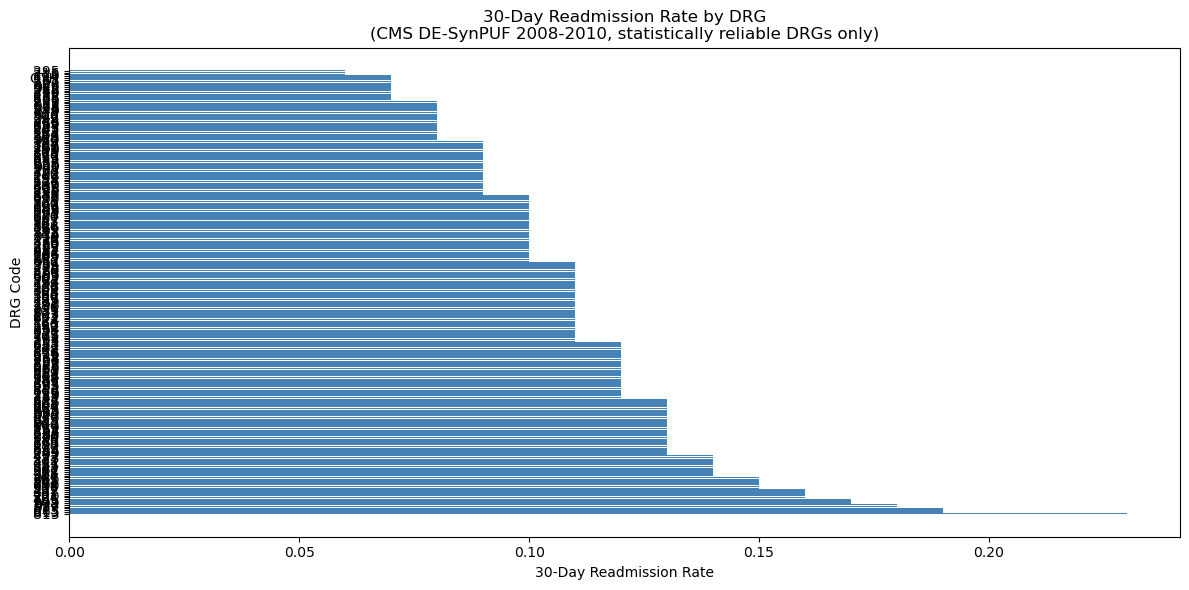

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.barh(df['CLM_DRG_CD'].astype(str), df['readmission_rate'], color='steelblue')
plt.xlabel('30-Day Readmission Rate')
plt.ylabel('DRG Code')
plt.title('30-Day Readmission Rate by DRG\n(CMS DE-SynPUF 2008-2010, statistically reliable DRGs only)')
plt.tight_layout()
plt.show()

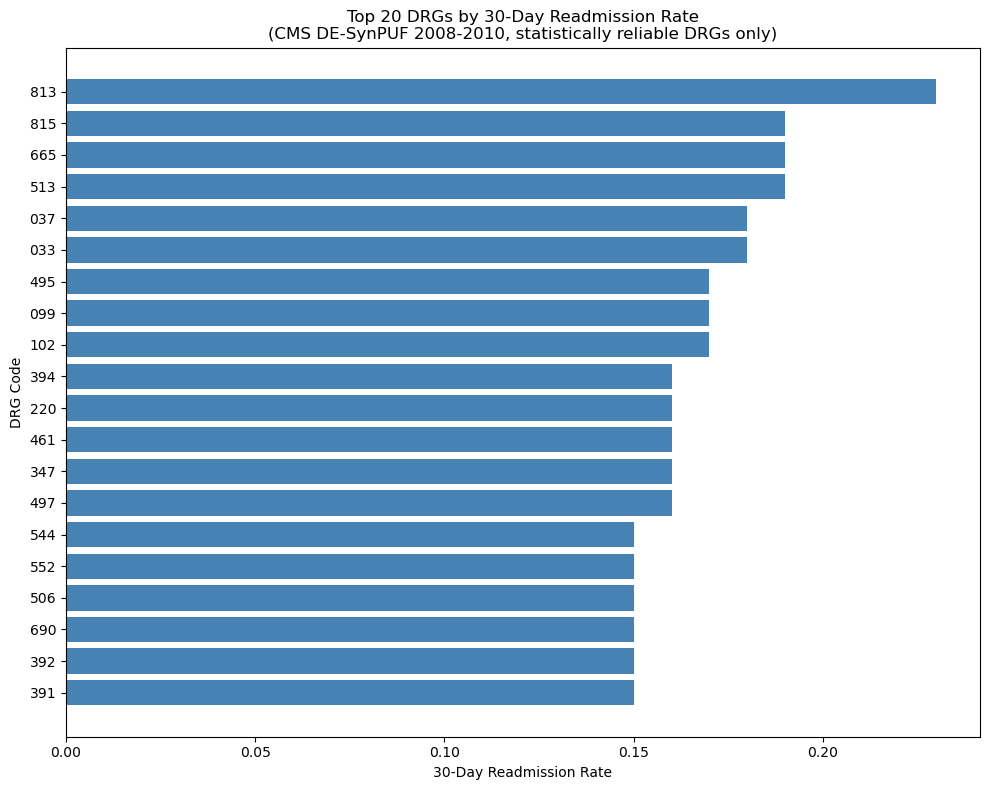

In [9]:
top20 = df.head(20).sort_values('readmission_rate')

plt.figure(figsize=(10, 8))
plt.barh(top20['CLM_DRG_CD'].astype(str), top20['readmission_rate'], color='steelblue')
plt.xlabel('30-Day Readmission Rate')
plt.ylabel('DRG Code')
plt.title('Top 20 DRGs by 30-Day Readmission Rate\n(CMS DE-SynPUF 2008-2010, statistically reliable DRGs only)')
plt.tight_layout()
plt.show()

Next analytical step: contrast observed DRG readmission rates against 
published CMS national Medicare 30-day readmission benchmark (~15%). 
Source needed — CMS Quality Payment Program or MedPAC annual report.